# Week5_Spatial Data 1

In today's lab, we will continue the topics of data management and visualization but focus on the spatial data analysis. *GeoPandas* provides powerful tools to perform spatial analysis in Python. Later, we will also cover other packages, such as Folium and OSMnx, which build on GeoPandas' **GeoDataFrame** capablities. 

After this week's lesson you should be able to:

- Read and write spatial data formats using GeoPandas
- Explore spatial data in a map
- Set and change map projections for GeoDataframes.
- Create GeoDataFrames with CSVs.
- Perform a spatial and attribute join.


This week's lessons are adapted from:
- Prof.Wenfei Xu's materials from CRP 5680 Spring 2023.
- [Automating GIS Processes Lesson 2](https://autogis-site.readthedocs.io/en/latest/lessons/lesson-2/overview.html)
- Dr.Wenzheng Li's materials from CRP 5680 Spring 2022.



<p><a id="Geopandas"> </a></p>
<h2 id="geopandasforspatialanalysis">1 <a href="#table">Geopandas?</a><a class="anchor-link" href="#geopandasforspatialanalysis">¶</a></h2>


**Geopandas** is a python library that allows us to manage, analyze, and map geospatial **vector** data. It combines what we have learned the tabular data analysis tools in **Pandas** with what will learn the geometry handling of **shapely** (a library for creating, analyzing, and manipulating geometric objects). Geopandas incorporates a python library called **fiona**, which handles all different kinds of spatial file formats, and **pyproj**, which manages our coordinate reference systems.

The main data structures in Geopandas are ``GeoDataFrames`` and ``GeoSeries``, which are intended to mirror the Pandas DataFrame and Series structures. This suggests that **most functionalities of pandas also work in geopandas**.

A GeoDataFrame incorporates three required elements:

- a ***DataFrame (df)***; 
- a ***geometry list*** : a shapely geometry list which defines the geometric object types of each observation, e.g., points, lines, or polygons. this is the column that makes GeoDataFrame different from DataFrame. 
<figure class="image">
<img src="https://autogis-site.readthedocs.io/en/2019/_images/geodataframe.png" alt="drawing" width="500" style="display: block; margin: 0 auto"/>
 <figcaption><center>(From Automating GIS Processes)</figcaption>
</figure>
    
- a ***crs*** (coordinate reference system presented by EPSG code, e.g., "epsg: 4326"); 
    - **EPSG** stands for European Petroleum Survey Group. They publish a database of coordinate system information plus some very good related documents on map projections and datums. **Each coordinate system corresponds to a unique EPSG code**. Check the link for more: https://epsg.org/home.html   

## 1.1 Geometric Objects


There are three kinds of fundamental geometric objects: 
- **Point** (zero-dimensional)
- **Line** (LineString) (one-dimensional)
- **Polygon** (two-dimensional)
  
In Shapely and spatial data structures like GeoJSON, these basic geometries can be extended into more complex structures to handle multiple features or combinations of different geometries.

<figure class="image">
<img src="https://autogis-site.readthedocs.io/en/latest/_images/simple-features_595x500px.svg" alt="drawing" width="500" style="display: block; margin: 0 auto"/>
 <figcaption>
    <center>Fundamental geometric objects (‘simple features’) that can be used in Python with 
    <a href="https://shapely.readthedocs.io/en/stable/" target="_blank">Shapely</a>. Figures by M. W. Toews; cf. Wikipedia’s article on GeoJSON
    </center>
</figcaption>
</figure>


<p><a id="creatingageodataframe"> </a></p>
<h2 id="creatingageodataframe">2 <a href="#table">Importing geospatial data</a><a class="anchor-link" href="#creatingageodataframe">¶</a></h2>


Please make sure you have the package Geopandas properly installed before running the following code. After installing it successfully, import the package `geopandas` and all other required pacakges for this lab: `pandas`, `numpy`, and `matplotlib`.     


In [3]:
# We are going to start importing the libraries we need
# all in one cell. 
# It is a good practice to keep all the imports in one cell so that
# we can easily see what libraries we are using in the notebook.

# Import geopandas module and assign it the nickname gpd
import geopandas as gpd

import pandas as pd
import numpy as np
import seaborn as sns

# Import the pyplot module from matplotlib and assign it the nickname plt
from matplotlib import pyplot as plt

# Ensures plots are displayed inline within the Jupyter Notebook
%matplotlib inline

# Warnings: Suppresses unnecessary warning messages to keep the output clean
import warnings
warnings.filterwarnings("ignore")

Today, we will primarily working on two datasets. 
- The first one is the Locations of **NYC Subway Stations**. 
- The second one is **the Locations of the public housing developments** of the New York City Housing Authority (NYCHA) as of January 2024. We will analyze the public housing accessibility from a transit perspective.

Before we get started, let's orient where we are in our directory:

In [4]:
# get your jupyter notebook path
import os
path = os.getcwd()


Now, let us import the two datasets by doing the following: 
- download the NYC Subway Stations from Canvas. 
- download the NYCHA public housing data from [the NYC Open Data Portal](https://data.cityofnewyork.us/Housing-Development/NYCHA-Public-Housing-Developments/phvi-damg/about_data).
    - Select **Export** in the upper-right hand corner of the page and and select **Shapefile**. 
- save these (zipped) files in the same folder as your codebook.
- notice that we can keep them as zipped files, as Geopandas can read both the zipped and unzipped version of the shapefile. The NYC OpenData Portal names the unzipped files (e.g., .shp, .prj) difficult to read, so it is better to keep them zipped...

Because of fiona's great under the hood functionality, Geopandas supports almost every vector spatial data format. For us, the most common formats will be ESRI shapefiles and GeoJSONs.

We can use the function `gdf.read_file()` to import two files as a GeoDataFrame.

In [4]:
# Now let's assign the variable name `gdf_stations` to the geodataframe
# These file names have spaces in them, which, as a reminder, 
# you should not do in your own work!
gdf_station = gpd.read_file("Subway Stations.zip")
gdf_housing = gpd.read_file("NYCHA Public Housing Developments_20250219.zip")

## 3. Initial Data Exploration

Once we've read in the file, let's first take a look at the subway stations data. 

In [9]:
# Same as you would do in Pandas - check the geodataframe
gdf_station.head()

,line,name,notes,objectid,url,geometry
0,4-6-6 Express,Astor Pl,"4 nights, 6-all times, 6 Express-weekdays AM s...",1.0,http://web.mta.info/nyct/service/,POINT (-73.99107 40.73005)
1,4-6-6 Express,Canal St,"4 nights, 6-all times, 6 Express-weekdays AM s...",2.0,http://web.mta.info/nyct/service/,POINT (-74.00019 40.71880)
2,1-2,50th St,"1-all times, 2-nights",3.0,http://web.mta.info/nyct/service/,POINT (-73.98385 40.76173)
3,2-3-4,Bergen St,"4-nights, 3-all other times, 2-all times",4.0,http://web.mta.info/nyct/service/,POINT (-73.97500 40.68086)
4,3-4,Pennsylvania Ave,"4-nights, 3-all other times",5.0,http://web.mta.info/nyct/service/,POINT (-73.89489 40.66471)


I'm sure somewhere online is the data dictionary (which I couldn't find :/) but this table contains what we'd expect: 

- `objectid` which is the unique ID number for each station
- `name` the name of the station 
- `line` which are all the lines that stop at that station
- `geometry` which is the shapely geometry that distinguishes this data from Pandas DataFrame
- `notes` which is the additionally useful information.

Let us take a look at the NYCHA data for public housing:

In [10]:
# check the first several rows of the NYCHA data: 
gdf_housing.head()

,developmen,tds_num,borough,geometry
0,1010 EAST 178TH STREET,180,BRONX,"POLYGON ((-73.88092 40.84050, -73.88068 40.840..."
1,1162-1176 WASHINGTON AVENUE,233,BRONX,"POLYGON ((-73.90694 40.83009, -73.90705 40.829..."
2,131 SAINT NICHOLAS AVENUE,154,MANHATTAN,"POLYGON ((-73.95286 40.80376, -73.95317 40.803..."
3,1471 WATSON AVENUE,214,BRONX,"POLYGON ((-73.88106 40.82640, -73.88099 40.826..."
4,154 WEST 84TH STREET,359,MANHATTAN,"POLYGON ((-73.97510 40.78591, -73.97528 40.785..."


Great! This dataset offers the metadata we need: 
- `borough`: NYC's five county-level administrative divisions (Manhattan - New York County; Bronx - Bronx County; Brooklyn - Kings County; Queens - Queens County; Staten Island - Richmond County).
- `developmen`: Development name.
- `TDS_NUM`: A unique identification number assigned to each development.
- `geometry`: Geometry column.

There's a typo in the column name where "development" is spelled "developmen". Let's fix that.

In [13]:
# rename "developmen" as "development"
gdf_housing.rename(columns = {"developmen": "development"}, inplace = True)
gdf_housing

,development,tds_num,borough,geometry
0,1010 EAST 178TH STREET,180,BRONX,"POLYGON ((-73.88092 40.84050, -73.88068 40.840..."
1,1162-1176 WASHINGTON AVENUE,233,BRONX,"POLYGON ((-73.90694 40.83009, -73.90705 40.829..."
2,131 SAINT NICHOLAS AVENUE,154,MANHATTAN,"POLYGON ((-73.95286 40.80376, -73.95317 40.803..."
3,1471 WATSON AVENUE,214,BRONX,"POLYGON ((-73.88106 40.82640, -73.88099 40.826..."
4,154 WEST 84TH STREET,359,MANHATTAN,"POLYGON ((-73.97510 40.78591, -73.97528 40.785..."
...,...,...,...,...
238,WSUR (BROWNSTONES),178,MANHATTAN,"MULTIPOLYGON (((-73.96927 40.78820, -73.96945 ..."
239,WSUR (SITE A) 120 WEST 94TH STREET,151,MANHATTAN,"POLYGON ((-73.96940 40.79186, -73.96960 40.791..."
240,WSUR (SITE B) 74 WEST 92ND STREET,173,MANHATTAN,"POLYGON ((-73.96889 40.79000, -73.96924 40.789..."
241,WSUR (SITE C) 589 AMSTERDAM AVENUE,174,MANHATTAN,"POLYGON ((-73.97318 40.78935, -73.97336 40.789..."


We can simply use [gdf.plot()](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html) to visualize GeoDataFrame.
   - remember to import the `matplotlib` and run `%matplotlib inline` to allow Jupyter Notebook to display a plot. 

<Axes: >

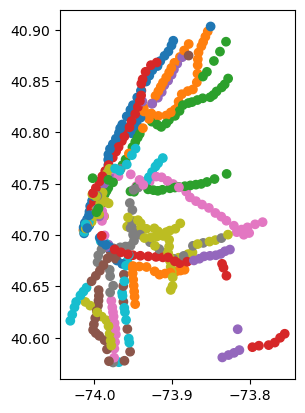

In [18]:
# plot the subway station dataset by line:
gdf_station.plot("line")

To make the plot look nicer, we can adjust the plotting parameters:
   - [marker](https://matplotlib.org/stable/api/markers_api.html): sets the shape of the marker used to represent data points in the plot.
   - markersize: sets the size of the markers in the plot
   - color: find the commonly used color: https://matplotlib.org/stable/gallery/color/named_colors.html), or check the ColorBrewer2 to find the appriopriate one for you. 

<Axes: >

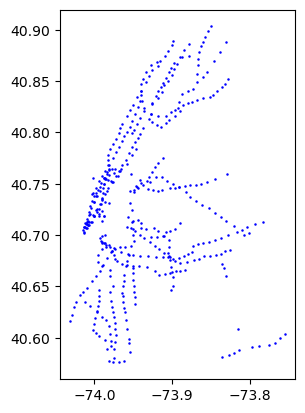

In [21]:
# To make the plot look nicer, we can adjust the plotting parameters
gdf_station.plot(marker = ".", markersize = 2.5, color = "blue")

Let us plot the public housing dataset.
- This look very faint, because we're working with building footprints at the scale of the entire city. That's ok. 

<Axes: >

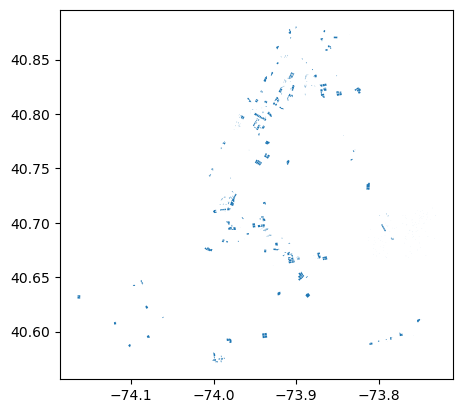

In [22]:
# Let us plot the public housing dataset.
gdf_housing.plot()

We can also check the CRS of the data
- both are EPSG:4326. This is the most widely used global CRS, using latitude and longitude coordinates based on the WGS 84 datum.

In [24]:
# check the crs of the data:
gdf_station.crs

<Geographic 2D CRS: GEOGCS["WGS84(DD)",DATUM["WGS84",SPHEROID["WGS84", ...>
Name: WGS84(DD)
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- undefined
Datum: WGS84
- Ellipsoid: WGS84
- Prime Meridian: Greenwich

In [25]:
gdf_housing.crs

<Geographic 2D CRS: GEOGCS["WGS84(DD)",DATUM["WGS84",SPHEROID["WGS84", ...>
Name: WGS84(DD)
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- undefined
Datum: WGS84
- Ellipsoid: WGS84
- Prime Meridian: Greenwich

## 4. Analyzing and manipulating data in geopandas

### 4.1 Changing Projections

Both datasets are currently in `EPSG: 4326`, the WGS1984 (World Geodetic System of 1984) with decimal degrees as coordinates. But I want to change my CRS to `EPSG:3857` - WGS 84/Pseudo-Mercator with metre as unit. This is a projected coordinate system (PCS) used for rendering maps in Google Maps, OpenStreetMap, etc.

To project to the target projection coordinate system ('EPSG:3857'), we use `gdf.to_crs()` on the GeoDataFrame.

In [26]:
# Note here that this function requires as an input
# the name of the new coordinate system
gdf_station.to_crs(3857)

,line,name,notes,objectid,url,geometry
0,4-6-6 Express,Astor Pl,"4 nights, 6-all times, 6 Express-weekdays AM s...",1.0,http://web.mta.info/nyct/service/,POINT (-8236648.235 4972605.859)
1,4-6-6 Express,Canal St,"4 nights, 6-all times, 6 Express-weekdays AM s...",2.0,http://web.mta.info/nyct/service/,POINT (-8237663.803 4970953.230)
2,1-2,50th St,"1-all times, 2-nights",3.0,http://web.mta.info/nyct/service/,POINT (-8235844.398 4977259.870)
3,2-3-4,Bergen St,"4-nights, 3-all other times, 2-all times",4.0,http://web.mta.info/nyct/service/,POINT (-8234859.237 4965382.255)
4,3-4,Pennsylvania Ave,"4-nights, 3-all other times",5.0,http://web.mta.info/nyct/service/,POINT (-8225941.072 4963012.202)
...,...,...,...,...,...,...
468,D-F-N-Q,Coney Island - Stillwell Av,"D,F,N,Q-all times",469.0,http://web.mta.info/nyct/service/,POINT (-8235553.520 4950189.238)
469,7-7 Express,34th St - Hudson Yards,"7-all times, 7 Express-rush hours AM westbound...",470.0,http://web.mta.info/nyct/service/,POINT (-8237886.898 4976336.703)
470,Q,72nd St,Q-all times,641.0,http://web.mta.info/nyct/service/,POINT (-8233007.174 4978299.664)
471,Q,86th St,Q-all times,642.0,http://web.mta.info/nyct/service/,POINT (-8232273.481 4979631.227)


Now let's check our dataset to make sure the CRS was changed:

In [27]:
gdf_station.crs

<Geographic 2D CRS: GEOGCS["WGS84(DD)",DATUM["WGS84",SPHEROID["WGS84", ...>
Name: WGS84(DD)
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- undefined
Datum: WGS84
- Ellipsoid: WGS84
- Prime Meridian: Greenwich

Hm, it wasn't changed! Why not?
- `gdf_station.to_crs (epsg=3857)` only returns re-projected geometry. If we do not re-assign our variable name `gdf_station` to this reprojected GeoDataFrame, the old version will not be updated.

Let us assign the revision to a variable name, and check the CRS again.

In [28]:
gdf_station.to_crs(epsg = 3857, inplace = True)

In [29]:
gdf_station.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

That worked! A good thing about using 3857 is that our units are in meters. This means that when we perform calculations on these geometries, the values we get are also going to be in meters.

Let us also change the CRS of the public housing dataset to `epsg=3857`:

In [30]:
gdf_housing = gdf_housing.to_crs(epsg=3857)

### 4.2 Basic Mapping

Let's talk about mapping in a bit more detail here.

You can also read the [GeoPandas user guide](https://geopandas.org/en/stable/docs/user_guide/mapping.html) for more on mapping. 

We can specify which column will determine the color schema of the plot. If the column is a numeric data type (`int` or `float`) `plot()` will try to create a **graduate color** map, if the column is a `str` or `obj`, it will try to create a **categorical** map.

In [35]:
# The column 'line' is an object type here
gdf_station.line.dtype

dtype('O')

In [36]:
# Not surprise, the column 'borough' is an object type here
gdf_housing.borough.dtype

dtype('O')

<Axes: >

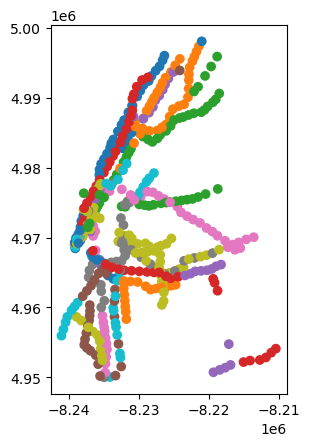

In [37]:
# plot the subway station by line
gdf_station.plot(column = "line")

# This plot is not very informative
# since there are many different combinations of lines that pass through 
# each station
# The map does not exactly line up with subway lines

Let us now map the subway stations and public housing in the same map. 
   - We can also add a background map (census tract of NYC), which can improve the readability of the map compared to a completely blank one.
   - To overlay plots of subway and public housing data on the same axes (subplot), you need to ensure that both datasets are plotted on the same Axes object. This can be done by plotting both datasets using the same ax (ax = ax).
   - Since the newly loaded data will be plotted on top of the existing data, unimportant data should be plotted first (e.g., basemap), and then data of interests. Sometimes, we also need to consider the spatial properties of the data to decide the plotting order (e.g., point data will be covered by polygon data).


In [40]:
# read the census tract shapefile
gdf_CT = gpd.read_file("2020 Census Tracts.zip")

# change to the same CRS
gdf_CT.to_crs(epsg = 3857, inplace = True)

<Axes: >

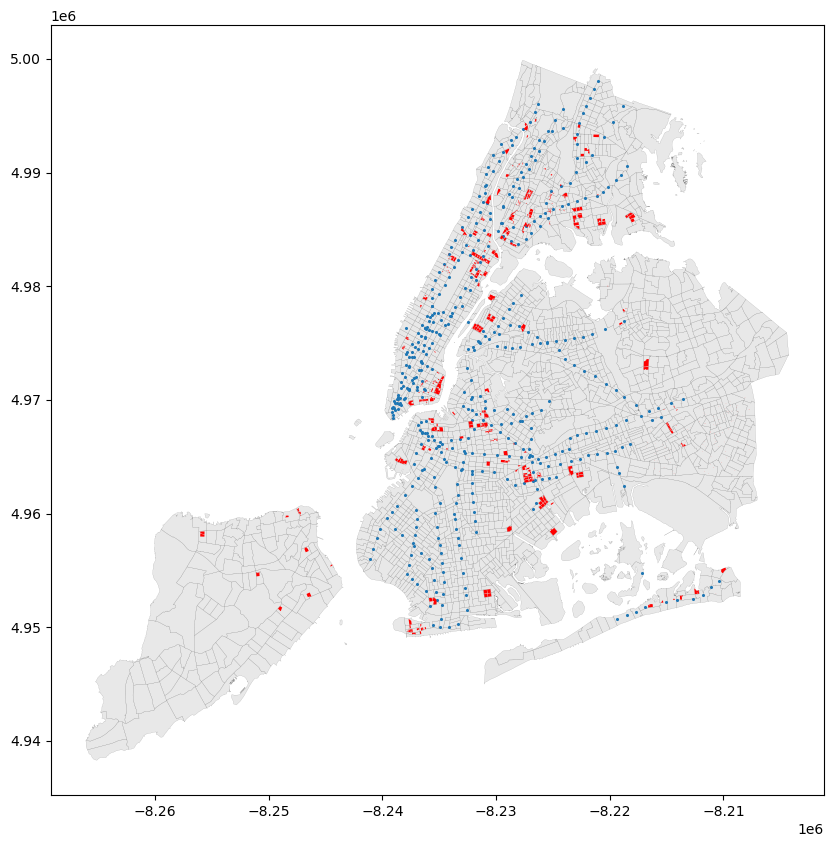

In [50]:
# create a plot
fig, ax = plt.subplots(figsize = (10,10))

# plot the census tract
# note that if you do not specify the "column", gdf.plot() will, by default, plot the spatial data (polygon/points/lines)
gdf_CT.plot(color = "lightgrey", alpha = 0.5 , edgecolor = "black", lw = 0.1, ax = ax)

# plot the subway stations 
gdf_station.plot(markersize = 1.5,  ax = ax)

# plot the housing dataset
gdf_housing.plot(color = "red", ax = ax)

## 5. Some geometric attributes

We can also check some geometric attributes that are unique to GeoDataFrame.

- obtain the x, y coordinates

In [53]:
# x coordinates
gdf_station.geometry.x

# y coordinates
gdf_station.geometry.y

0      4.972606e+06
1      4.970953e+06
2      4.977260e+06
3      4.965382e+06
4      4.963012e+06
           ...     
468    4.950189e+06
469    4.976337e+06
470    4.978300e+06
471    4.979631e+06
472    4.980569e+06
Length: 473, dtype: float64

- calculate area. The calculated area is in the current coordinate system. If your data uses a GCS (such as WGS84), the calculated area will be inaccurate. So, make sure your GeoDataFrame uses an appropriate PCS (such as meters or feet).

In [54]:
# calculate area
gdf_housing.geometry.area

0      14055.643848
1       3100.542315
2       4906.826076
3       6846.427410
4       1633.689927
           ...     
238    11269.595979
239     3718.371081
240     4171.072990
241     4116.831557
242    39399.503590
Length: 243, dtype: float64

<Axes: >

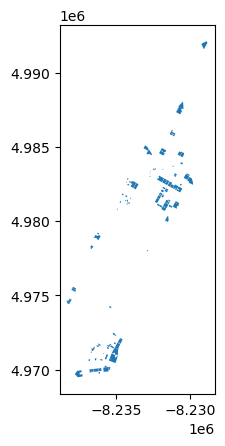

In [81]:
gdf_housing[gdf_housing.borough == "MANHATTAN"].buffer(10).plot()

# The buffer expands each geometry outward by 10 units.
# The unit depends on the coordinate reference system (CRS).
# If the CRS is in meters (EPSG:3857), then 10 meters is added around each geometry.

In [88]:
gdf_housing.distance(gdf_housing.centroid.iloc[0])

# gdf_housing.centroid: Computes the centroid (geometric center) of each polygon
# gdf_housing.centroid.iloc[0]: Selects the first centroid (row index 0)
# gdf_housing.distance(): Computes the spatial distance from each geometry in public_housing to the first centroid.

0          0.000000
1       3358.449164
2       9711.411292
3       2086.034936
4      13286.425251
           ...     
238    12300.108562
239    12255.652990
240    12372.984039
241    12813.303686
242    25864.797697
Length: 243, dtype: float64

<p><a id="DealingWithSpatialEquityIssue"> </a></p>
<h2 id="geopandasforspatialanalysis">6 <a href="#table">Dealing With Spatial Equity Issue</a><a class="anchor-link" href="#geopandasforspatialanalysis">¶</a></h2>


### 6.1 Creating a Buffer Area（Service Area)

Now, let us say we want to calculate **how many subway stations are within a 10 minute walk of each housing unit**. 

We are going to do this by: 
- Providing an estimate of the distance a typical person can walk in 10 minutes
- Creating a new geometry that is buffered around each building by that distance.

A quick google search tells me 10 minutes is about 800 meters based on average walking speeds. 

Let's make a new dataset that buffers each building with a 800 meter distance, using the [GeoSeries.buffer](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.buffer.html) function, but still has the original tabular data of our public housing dataset. Recall that a GeoDataFrame takes a **dataframe, a CRS, and a set of geometries**.

In [55]:
# Make sure that your housing dataset is correctly projected. 
gdf_housing.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [60]:
gdf_housing.columns

Index(['development', 'tds_num', 'borough', 'geometry'], dtype='object')

In [61]:
# First, let's make our geometries
buffer_geom = gdf_housing.geometry.buffer(800)

# Second, we already know the CRS
# This the same as the CRS of public housing data 
buffer_crs = gdf_housing.crs

# Third, let's grab the data we want
buffer_data = gdf_housing[["development", "tds_num", "borough"]]

# Now, let's put it all together using the GeoDataFrame constructor
gdf_housing_buffer = gpd.GeoDataFrame(data = buffer_data, crs = buffer_crs, geometry = buffer_geom)

In [63]:
gdf_housing_buffer

,development,tds_num,borough,geometry
0,1010 EAST 178TH STREET,180,BRONX,"POLYGON ((-8225180.045 4988937.223, -8225178.0..."
1,1162-1176 WASHINGTON AVENUE,233,BRONX,"POLYGON ((-8226967.873 4988047.243, -8226897.5..."
2,131 SAINT NICHOLAS AVENUE,154,MANHATTAN,"POLYGON ((-8231595.644 4983474.449, -8231595.9..."
3,1471 WATSON AVENUE,214,BRONX,"POLYGON ((-8223750.142 4987257.667, -8223722.5..."
4,154 WEST 84TH STREET,359,MANHATTAN,"POLYGON ((-8234481.468 4981514.429, -8234414.8..."
...,...,...,...,...
238,WSUR (BROWNSTONES),178,MANHATTAN,"POLYGON ((-8235049.879 4981271.489, -8235062.2..."
239,WSUR (SITE A) 120 WEST 94TH STREET,151,MANHATTAN,"POLYGON ((-8233846.752 4982388.142, -8233780.2..."
240,WSUR (SITE B) 74 WEST 92ND STREET,173,MANHATTAN,"POLYGON ((-8233791.860 4982115.411, -8233725.2..."
241,WSUR (SITE C) 589 AMSTERDAM AVENUE,174,MANHATTAN,"POLYGON ((-8234268.566 4982019.499, -8234202.0..."


<Axes: >

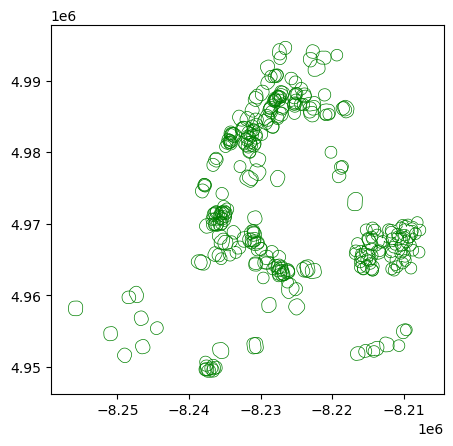

In [70]:
# Note that I've started new lines for each argument to make it easier to read
gdf_housing_buffer.plot(edgecolor = "green", facecolor = "none", lw = 0.5)

Whoa, what happened here?? Beyond setting the figure size, I'm including other optional inputs that allows me to style these more clearly. 
- `facecolor` is the fill color, which I want to set to "none" to make the polygons transparent
- `edgecolor` is the edge color, and `plot()` [recognizes certain named colors](https://matplotlib.org/stable/gallery/color/named_colors.html). 
- `lw` allows me to set the line weight. 

### 6.2 Spatial join

Now, let us count how many subway stations are in each buffer to get a sense of transit accessibility by using a **spatial join** between our new `gdf_housing_buffer` dataset and our `subway_stops` dataset. 

We are going to use  [gpd.sjoin(left_geoDF,right_geoDF)](https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html). This function optionally takes as an input `how` to specify what type of spatial join. 

There are couple of different types of spatial joins: 
- `Left outer join`: In a LEFT OUTER JOIN (how='left'), we keep all rows from the left and duplicate them if necessary to represent multiple hits between the two dataframes. We retain attributes of the right if they intersect and lose right rows that don’t intersect. A left outer join implies that we are interested in **retaining the geometry column of the left**.


- `Right outer join`: In a RIGHT OUTER JOIN (how='right'), we keep all rows from the right and duplicate them if necessary to represent multiple hits between the two dataframes. We retain attributes of the left if they intersect and lose left rows that don’t intersect. A right outer join implies that we are interested in **retaining the geometries of the right**.


- `Inner join` (this is the default setting): In an INNER JOIN (how='inner'), we keep rows from the right and left only where their binary predicate is True. We duplicate them if necessary to represent multiple hits between the two dataframes. We **retain attributes of the right and left only if they intersect** and lose all rows that do not. An inner join implies that we are interested in retaining the geometries of the left.


In this case, we want to join `gdf_housing_buffer` and `gdf_stations` and a **left outer join** because we want to keep the hits between our public housing buffer and the subway stations within the buffer zone. 

In [73]:
# Before we assign this to a new variable, 
# let's check to see what the join looks like
gpd.sjoin(gdf_housing_buffer, gdf_station, how = "left")

,development,tds_num,borough,geometry,index_right,line,name,notes,objectid,url
0,1010 EAST 178TH STREET,180,BRONX,"POLYGON ((-8225180.045 4988937.223, -8225178.0...",271.0,2-5,West Farms Sq - E Tremont Av,"2-all times, 5-all times exc nights, skips rus...",272.0,http://web.mta.info/nyct/service/
0,1010 EAST 178TH STREET,180,BRONX,"POLYGON ((-8225180.045 4988937.223, -8225178.0...",284.0,2-5,E 180th St,"2,5-all times",285.0,http://web.mta.info/nyct/service/
1,1162-1176 WASHINGTON AVENUE,233,BRONX,"POLYGON ((-8226967.873 4988047.243, -8226897.5...",NaN,NaN,NaN,NaN,NaN,NaN
2,131 SAINT NICHOLAS AVENUE,154,MANHATTAN,"POLYGON ((-8231595.644 4983474.449, -8231595.9...",6.0,A-B-C,Cathedral Pkwy (110th St),"A-nights, B-weekdays and evenings, C-all times...",7.0,http://web.mta.info/nyct/service/
2,131 SAINT NICHOLAS AVENUE,154,MANHATTAN,"POLYGON ((-8231595.644 4983474.449, -8231595.9...",159.0,2-3,Central Park North (110th St),"2,3-all times",160.0,http://web.mta.info/nyct/service/
...,...,...,...,...,...,...,...,...,...,...
242,WYCKOFF GARDENS,163,BROOKLYN,"POLYGON ((-8235337.995 4966372.022, -8235270.0...",35.0,D-N-R,Union St,"D,N-nights, R-all other times",36.0,http://web.mta.info/nyct/service/
242,WYCKOFF GARDENS,163,BROOKLYN,"POLYGON ((-8235337.995 4966372.022, -8235270.0...",366.0,A-C-G,Hoyt - Schermerhorn Sts,"A,G-all times, C-all times exc nights",367.0,http://web.mta.info/nyct/service/
242,WYCKOFF GARDENS,163,BROOKLYN,"POLYGON ((-8235337.995 4966372.022, -8235270.0...",121.0,D-N-Q-R,Atlantic Av - Barclay's Center,"D,N-all times, R-all times exc nights",122.0,http://web.mta.info/nyct/service/
242,WYCKOFF GARDENS,163,BROOKLYN,"POLYGON ((-8235337.995 4966372.022, -8235270.0...",115.0,2-3-4-5,Atlantic Av - Barclay's Center,"2,4-all times, 3-all times exc nights, 5-weekdays",116.0,http://web.mta.info/nyct/service/


As we can, see there are duplicate rows of the buffers where each buffered geometry has intersected with multiple stations.

Great, since that looked like it worked, let's assign it to a new variable name: 

In [75]:
# let us do the spatial join
gdf_housing_buffer_sjoin = gpd.sjoin(gdf_housing_buffer, gdf_station, how = "left")
    

We can use the `.groupby()` and `.count()` to count the number of subways within the buffer of each public housing. 

In [83]:
# grouped by "development" and count
station_counts = gdf_housing_buffer_sjoin.groupby("development")[["objectid"]].count().reset_index()


Let us look at the distribution of the number of subway stations: 
- use `.value_counts()` to count the frequency of unique values
- use `.hist()` to visualize the distribution

In [87]:
# let us first sort the data: 
station_counts.sort_values(by = "objectid", ascending = False, inplace = True)

# then rename "objectid" to ""no_stations
station_counts.rename(columns = {"objectid": "no_stations"}, inplace = True)

,development,no_stations
131,LOWER EAST SIDE I INFILL,8
79,FHA REPOSSESSED HOUSES (GROUP IX),8
14,ATLANTIC TERMINAL SITE 4B,7
158,OCEAN HILL APARTMENTS,6
138,MARLBORO,6
...,...,...
195,SOUTH BEACH,0
196,SOUTH JAMAICA I,0
82,FHA REPOSSESSED HOUSES (GROUP VII),0
38,CAREY GARDENS,0


In [88]:
# .value_counts()
station_counts.no_stations.value_counts()

no_stations
0    69
2    51
1    42
3    31
4    27
5    15
6     5
8     2
7     1
Name: count, dtype: int64

In [94]:
# Convert value_counts() output to a DataFrame
df_barplot = station_counts.no_stations.value_counts().reset_index()
df_barplot.columns = ["no_stations", "count"]

<Axes: xlabel='no_stations', ylabel='count'>

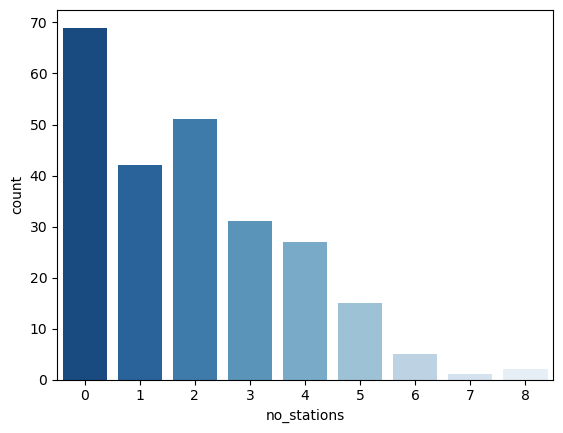

In [96]:
# Add histogram plot using Seaborn
sns.barplot(data=df_barplot, x="no_stations", y="count", palette="Blues_r")

### 6.3 Attribute joins (.merge)

You may notice that the `station_counts` does not include the spatial information. Now, let's join this back to our `gdf_housing_buffer` GeoDataFrame so we can map it.

In an attribute join, a `GeoSeries` or `GeoDataFrame` is combined with a regular `pandas.Series` or `pandas.DataFrame` based on a common variable. This is analogous to normal merging or joining in pandas.

This is what a merge looks like visually

</figure>
<img src="https://miro.medium.com/max/1400/1*ZCpo3gXuXI4KFhKivEt2ZA.png " alt="drawing" width="700" style="display: block; margin: 0 auto"/>
</figure>




In the .merge() function, try both how = "inner" and how = "left". What is the difference? From the Pandas user guide (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html):

- how{‘left’, ‘right’, ‘outer’, ‘inner’, ‘cross’}, default ‘inner’ 
- Type of merge to be performed.
    - left: use only keys from left frame; preserve key order.
    - right: use only keys from right frame; preserve key order.
    - outer: use union of keys from both frames; sort keys lexicographically.
    - inner: use intersection of keys from both frames; preserve the order of the left keys.

In [154]:
# Find the merge key: 
station_counts

,development,no_stations
131,LOWER EAST SIDE I INFILL,8
79,FHA REPOSSESSED HOUSES (GROUP IX),8
14,ATLANTIC TERMINAL SITE 4B,7
158,OCEAN HILL APARTMENTS,6
138,MARLBORO,6
...,...,...
78,FHA REPOSSESSED HOUSES (GROUP IV),0
77,FHA REPOSSESSED HOUSES (GROUP III),0
45,CLAREMONT REHAB (GROUP 2),0
76,FHA REPOSSESSED HOUSES (GROUP II),0


In [155]:
# Find the merge key: development
gdf_housing_buffer

,borough,development,tds_num,geometry
0,BRONX,1010 EAST 178TH STREET,180,"POLYGON ((-8225180.045 4988937.223, -8225178.0..."
1,BRONX,1162-1176 WASHINGTON AVENUE,233,"POLYGON ((-8226967.873 4988047.243, -8226897.5..."
2,MANHATTAN,131 SAINT NICHOLAS AVENUE,154,"POLYGON ((-8231595.644 4983474.449, -8231595.9..."
3,BRONX,1471 WATSON AVENUE,214,"POLYGON ((-8223750.142 4987257.667, -8223722.5..."
4,MANHATTAN,154 WEST 84TH STREET,359,"POLYGON ((-8234481.468 4981514.429, -8234414.8..."
...,...,...,...,...
238,MANHATTAN,WSUR (BROWNSTONES),178,"POLYGON ((-8235049.879 4981271.489, -8235062.2..."
239,MANHATTAN,WSUR (SITE A) 120 WEST 94TH STREET,151,"POLYGON ((-8233846.752 4982388.142, -8233780.2..."
240,MANHATTAN,WSUR (SITE B) 74 WEST 92ND STREET,173,"POLYGON ((-8233791.860 4982115.411, -8233725.2..."
241,MANHATTAN,WSUR (SITE C) 589 AMSTERDAM AVENUE,174,"POLYGON ((-8234268.566 4982019.499, -8234202.0..."


Now, we can determine that the merge key is development column.

We will now merge `station_counts` to the `gdf_housing_buffer` that stores spatial information. 

In [157]:
# .merge()
gdf_housing_buffer.merge(station_counts, 
                            left_on='development', 
                            right_on='development')

# we keep the default setting: how='inner' 

,borough,development,tds_num,geometry,no_stations
0,BRONX,1010 EAST 178TH STREET,180,"POLYGON ((-8225180.045 4988937.223, -8225178.0...",2
1,BRONX,1162-1176 WASHINGTON AVENUE,233,"POLYGON ((-8226967.873 4988047.243, -8226897.5...",0
2,MANHATTAN,131 SAINT NICHOLAS AVENUE,154,"POLYGON ((-8231595.644 4983474.449, -8231595.9...",4
3,BRONX,1471 WATSON AVENUE,214,"POLYGON ((-8223750.142 4987257.667, -8223722.5...",2
4,MANHATTAN,154 WEST 84TH STREET,359,"POLYGON ((-8234481.468 4981514.429, -8234414.8...",4
...,...,...,...,...,...
238,MANHATTAN,WSUR (BROWNSTONES),178,"POLYGON ((-8235049.879 4981271.489, -8235062.2...",4
239,MANHATTAN,WSUR (SITE A) 120 WEST 94TH STREET,151,"POLYGON ((-8233846.752 4982388.142, -8233780.2...",2
240,MANHATTAN,WSUR (SITE B) 74 WEST 92ND STREET,173,"POLYGON ((-8233791.860 4982115.411, -8233725.2...",4
241,MANHATTAN,WSUR (SITE C) 589 AMSTERDAM AVENUE,174,"POLYGON ((-8234268.566 4982019.499, -8234202.0...",3


That worked! Let's update our public_housing_buffer variable name to point to our updated geodataframe with this new column.

In [162]:
# .merge()
gdf_housing_buffer = gdf_housing_buffer.merge(station_counts, 
                            left_on='development', 
                            right_on='development')

# we keep the default setting: how='inner' 

### 6.4 Plotting the spatially joined data

Let us now mapping the accessibility to the subway stations. 
- *`cmap`*: The default color map (cmap) in GeoPandas is viridis. You can find other ones [here](https://matplotlib.org/stable/gallery/color/colormap_reference.html). Let's change our color map to coolwarm

<Axes: >

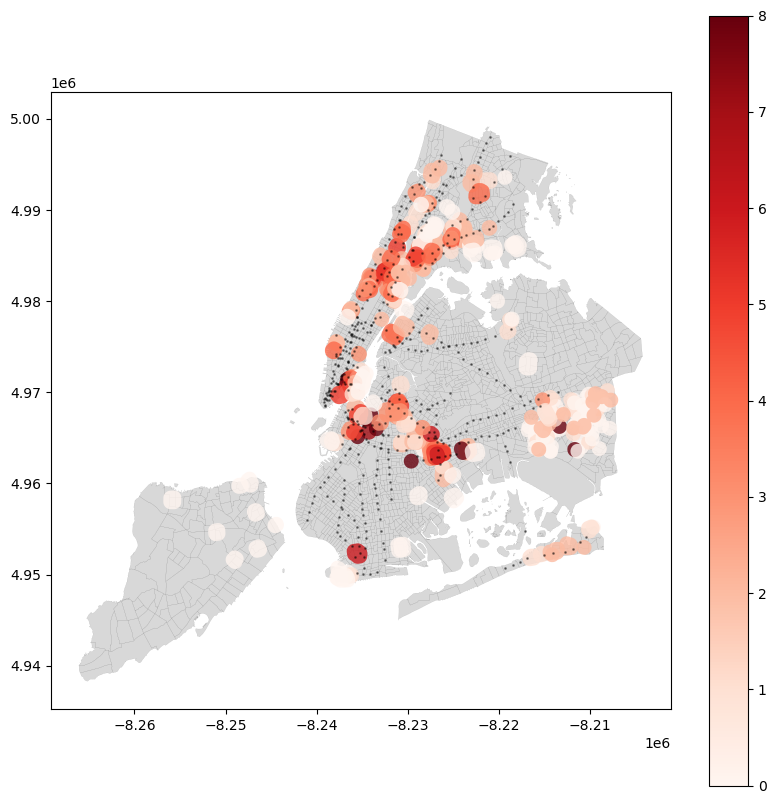

In [197]:
# plt.subplots() returns a tuple of the figure and the axis, 
# which we are assigning to fig and ax, respectively

# Note that using this method of creating a plot, 
# we set the figure size using the figsize argument in plt.subplots()
fig, ax = plt.subplots(figsize = (10, 10))

# The drawing order is determined by the order in which we call the plot methods

# We can use the ax argument to specify the axis we want to plot on
# Here, we're plotting the public housing buffer on the axis we just created

# plot the census tract as the basemap
gdf_CT.plot(color='grey', 
            alpha = 0.3, 
            edgecolor='black', 
            linewidth = 0.1, 
            ax = ax)

# plot the number of subway stations for public housing
gdf_housing_buffer.plot(column = "no_stations",
                        cmap = 'Reds', 
                        legend = True, 
                        alpha=0.8,
                        ax = ax)
# plot subway stations
gdf_station.plot(markersize=1,
            color='black',
                 alpha=0.4,
            ax=ax)

Still not a great map, but at least we have a bit more context.

<p><a id="Writingtoafile"> </a></p>
<h2 id="geopandasforspatialanalysis">7 <a href="#table">Writing to a file</a><a class="anchor-link" href="#geopandasforspatialanalysis">¶</a></h2>

Now let us write this buffer data we've created to a file. The default is writing to a ``shapefile``. 

In [198]:
# this will write to a folder containing a .shp, .shx, .dbf, and .prj file
gdf_housing_buffer.to_file('public_housing_buffer')

In [199]:
# This will write to a single .geojson file
# You need to specify the driver
gdf_housing_buffer.to_file('public_housing_buffer_geojson',driver='GeoJSON')

## In-Class Exercise 1
Which building or buildings have the highest| number of stations within a 10 min walk? Show the code you used to get this answer. 

In [202]:
gdf_housing_buffer.no_stations.sort_values(ascending = False)
gdf_housing_buffer[gdf_housing_buffer.no_stations == 8]

,borough,development,tds_num,geometry,no_stations
79,NaN,FHA REPOSSESSED HOUSES (GROUP IX),283,"MULTIPOLYGON (((-8210883.375 4963782.671, -821...",8
131,MANHATTAN,LOWER EAST SIDE I INFILL,326,"POLYGON ((-8237434.550 4971435.939, -8237433.8...",8


In [206]:
gdf_housing_buffer[gdf_housing_buffer['geometry'].type=='MultiPolygon']

,borough,development,tds_num,geometry,no_stations
75,NaN,FHA REPOSSESSED HOUSES (GROUP I),209,"MULTIPOLYGON (((-8212229.562 4968459.234, -821...",0
76,NaN,FHA REPOSSESSED HOUSES (GROUP II),212,"MULTIPOLYGON (((-8208407.728 4967075.083, -820...",0
77,NaN,FHA REPOSSESSED HOUSES (GROUP III),213,"MULTIPOLYGON (((-8208628.915 4964531.780, -820...",0
78,NaN,FHA REPOSSESSED HOUSES (GROUP IV),226,"MULTIPOLYGON (((-8207533.375 4966787.949, -820...",0
79,NaN,FHA REPOSSESSED HOUSES (GROUP IX),283,"MULTIPOLYGON (((-8210883.375 4963782.671, -821...",8
80,NaN,FHA REPOSSESSED HOUSES (GROUP V),260,"MULTIPOLYGON (((-8216504.406 4964161.017, -821...",1
81,NaN,FHA REPOSSESSED HOUSES (GROUP VI),273,"MULTIPOLYGON (((-8211320.931 4967942.520, -821...",0
82,NaN,FHA REPOSSESSED HOUSES (GROUP VII),274,"MULTIPOLYGON (((-8208319.459 4969460.328, -820...",0
83,NaN,FHA REPOSSESSED HOUSES (GROUP VIII),275,"MULTIPOLYGON (((-8209427.143 4965640.754, -820...",0
84,NaN,FHA REPOSSESSED HOUSES (GROUP X),284,"MULTIPOLYGON (((-8211370.407 4966772.879, -821...",2


## In-Class Exercise 2
Create a new column called `area` in `public_housing_buffer` that the area of the original building footprints in meters. (Hint: you'll need to do a `merge`.)

In [211]:
gdf_housing["area_meter"] = gdf_housing.geometry.area 

In [218]:
gdf_combine = gdf_housing_buffer.merge(
    gdf_housing, on="development", how="left", suffixes=('', '_drop')
)

In [220]:
gdf_combine.drop(columns=[col for col in gdf_combine.columns if col.endswith('_drop')], inplace = True)

In [221]:
gdf_combine

,borough,development,tds_num,geometry,no_stations,area_meter
0,BRONX,1010 EAST 178TH STREET,180,"POLYGON ((-8225180.045 4988937.223, -8225178.0...",2,14055.643848
1,BRONX,1162-1176 WASHINGTON AVENUE,233,"POLYGON ((-8226967.873 4988047.243, -8226897.5...",0,3100.542315
2,MANHATTAN,131 SAINT NICHOLAS AVENUE,154,"POLYGON ((-8231595.644 4983474.449, -8231595.9...",4,4906.826076
3,BRONX,1471 WATSON AVENUE,214,"POLYGON ((-8223750.142 4987257.667, -8223722.5...",2,6846.427410
4,MANHATTAN,154 WEST 84TH STREET,359,"POLYGON ((-8234481.468 4981514.429, -8234414.8...",4,1633.689927
...,...,...,...,...,...,...
238,MANHATTAN,WSUR (BROWNSTONES),178,"POLYGON ((-8235049.879 4981271.489, -8235062.2...",4,11269.595979
239,MANHATTAN,WSUR (SITE A) 120 WEST 94TH STREET,151,"POLYGON ((-8233846.752 4982388.142, -8233780.2...",2,3718.371081
240,MANHATTAN,WSUR (SITE B) 74 WEST 92ND STREET,173,"POLYGON ((-8233791.860 4982115.411, -8233725.2...",4,4171.072990
241,MANHATTAN,WSUR (SITE C) 589 AMSTERDAM AVENUE,174,"POLYGON ((-8234268.566 4982019.499, -8234202.0...",3,4116.831557


In [222]:
gdf_combine.to_file('gdf_combine')

## In-Class Exercise 3
- From the NYC open data portal, download a [shapefile of neighborhoods](https://data.cityofnewyork.us/City-Government/2020-Neighborhood-Tabulation-Areas-NTAs-/9nt8-h7nd/about_data)
- Make sure to change the CRS so it matches the other layers. 
- Add it to the map in section 6.4 *first* to replace census tract boundary (i.e. below the other layers)
- Make the fill color of the neighorhoods `lightgray`.


## In-Class Exercise 4 - OPTIONAL 
Separately, create a choropleth map that shows the number of subway stations in each neighborhood. 